In [ ]:
!pip install tensorflow
!pip install matplotlib
!pip install scikit-learn
!pip install tqdm


## JUST FOR CUDA USERS:
#from tensorflow.keras import backend as K
#import tensorflow as tf
#K.clear_session()
#tf.compat.v1.reset_default_graph()
# tf.config.set_visible_devices([], 'GPU')

^C


## APRENDIZAJE FEDERADO.

El aprendizaje federado consiste en entrenar un modelo localmente con un subconjunto de datos, para después computar un modelo global (idéntico) que será desplegado como un servicio.

Para simular una situación de aprendizaje federado, usaremos la bien-conocida base de datos MNIST para interpretar número escritos a mano, y la dividiremos en cinco partes (en su caso, será en cuantos miembros de su equipo tengan).

11490434/11490434 [==============================] - 27s 2us/step


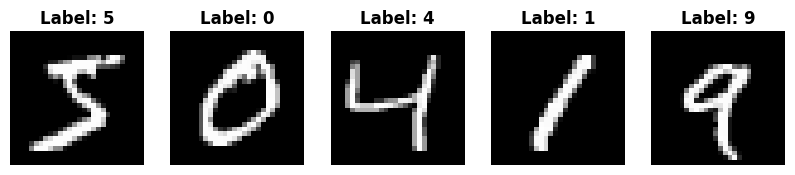

12000
Frecuencia de números: {0: 1184, 1: 1348, 2: 1191, 3: 1227, 4: 1169, 5: 1085, 6: 1183, 7: 1253, 8: 1170, 9: 1190}
Primeros ejemplos (labels): [5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1]
12000
Frecuencia de números: {0: 1185, 1: 1349, 2: 1191, 3: 1226, 4: 1168, 5: 1084, 6: 1184, 7: 1253, 8: 1170, 9: 1190}
Primeros ejemplos (labels): [7, 7, 7, 7, 7, 7, 6, 7, 7, 6, 6, 7, 0, 7, 6]
12000
Frecuencia de números: {0: 1185, 1: 1349, 2: 1192, 3: 1226, 4: 1168, 5: 1084, 6: 1184, 7: 1253, 8: 1170, 9: 1189}
Primeros ejemplos (labels): [3, 3, 3, 3, 9, 3, 9, 9, 3, 3, 3, 9, 9, 1, 9]
12000
Frecuencia de números: {0: 1185, 1: 1348, 2: 1192, 3: 1226, 4: 1168, 5: 1084, 6: 1184, 7: 1253, 8: 1170, 9: 1190}
Primeros ejemplos (labels): [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 9, 9, 9, 1, 9]
12000
Frecuencia de números: {0: 1184, 1: 1348, 2: 1192, 3: 1226, 4: 1169, 5: 1084, 6: 1183, 7: 1253, 8: 1171, 9: 1190}
Primeros ejemplos (labels): [1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 1, 9, 1, 1, 1]


In [1]:
import tensorflow as tf
import numpy as np

train, test = tf.keras.datasets.mnist.load_data()

x_train, x_test = np.expand_dims(train[0] / 255.0, -1), np.expand_dims(test[0] / 255.0, -1)
y_train, y_test = train[1], test[1]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()


## Data split para simular cinco datos aparte.
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5)

folds = skf.split(x_train, y_train)

local_data = [(x_train[tsix], y_train[tsix]) for trix, tsix in folds]

for x in local_data:
    print(len(x[0]))
    print(f"Frecuencia de números: { {int(y):list(x[1]).count(y) for y in set(x[1])} }")
    print(f"Primeros ejemplos (labels): {[int(y) for y in list(x[1])[:15]]}")

FOLD (array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[

Epoch 1/5
375/375 [==============================] - 9s 21ms/step - loss: 0.3735 - accuracy: 0.8915 - val_loss: 0.1275 - val_accuracy: 0.9582
Epoch 2/5
375/375 [==============================] - 7s 20ms/step - loss: 0.1020 - accuracy: 0.9681 - val_loss: 0.0800 - val_accuracy: 0.9747
Epoch 3/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0651 - accuracy: 0.9800 - val_loss: 0.0581 - val_accuracy: 0.9811
Epoch 4/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0484 - accuracy: 0.9846 - val_loss: 0.0657 - val_accuracy: 0.9772
Epoch 5/5
313/313 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.94      0.99      0.96      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.9

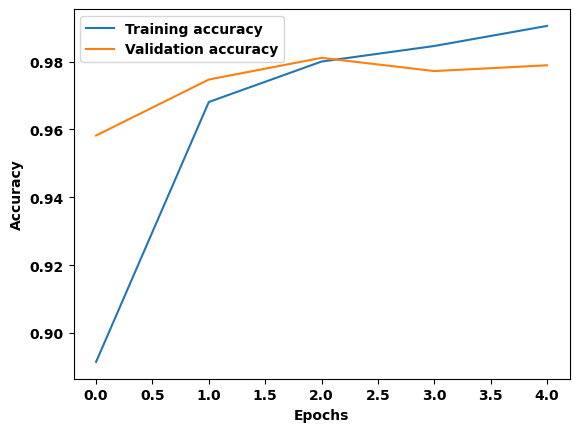

FOLD (array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[

Epoch 1/5
375/375 [==============================] - 9s 22ms/step - loss: 0.3585 - accuracy: 0.8941 - val_loss: 0.1041 - val_accuracy: 0.9684
Epoch 2/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0893 - accuracy: 0.9722 - val_loss: 0.0734 - val_accuracy: 0.9778
Epoch 3/5
375/375 [==============================] - 6s 17ms/step - loss: 0.0589 - accuracy: 0.9808 - val_loss: 0.0693 - val_accuracy: 0.9796
Epoch 4/5
375/375 [==============================] - 6s 17ms/step - loss: 0.0393 - accuracy: 0.9874 - val_loss: 0.0569 - val_accuracy: 0.9821
Epoch 5/5
313/313 [==============================] - 2s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.98      0.98      0.98      1010
           4       1.00      0.98      0.99       982
           5       0.96      0.99      0.9

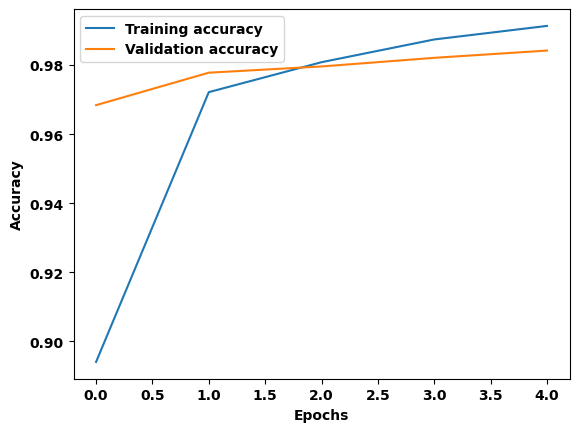

FOLD (array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[

Epoch 1/5
375/375 [==============================] - 7s 17ms/step - loss: 0.3742 - accuracy: 0.8889 - val_loss: 0.1185 - val_accuracy: 0.9618
Epoch 2/5
375/375 [==============================] - 7s 18ms/step - loss: 0.0987 - accuracy: 0.9690 - val_loss: 0.0772 - val_accuracy: 0.9774
Epoch 3/5
375/375 [==============================] - 6s 17ms/step - loss: 0.0657 - accuracy: 0.9789 - val_loss: 0.0680 - val_accuracy: 0.9784
Epoch 4/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0437 - accuracy: 0.9861 - val_loss: 0.0623 - val_accuracy: 0.9794
Epoch 5/5
313/313 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.95      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.97      1.00      0.98       982
           5       0.95      0.99      0.9

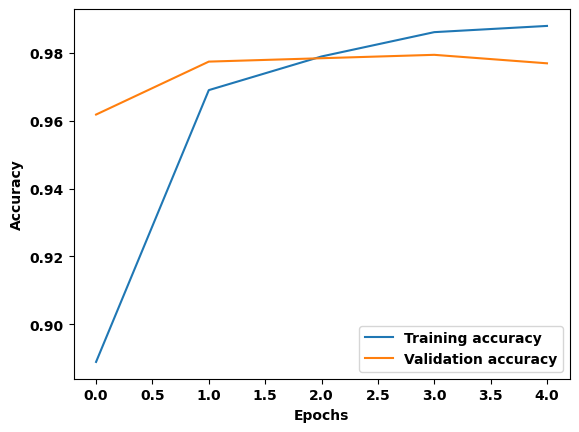

FOLD (array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[

Epoch 1/5
375/375 [==============================] - 7s 17ms/step - loss: 0.3861 - accuracy: 0.8842 - val_loss: 0.1168 - val_accuracy: 0.9645
Epoch 2/5
375/375 [==============================] - 6s 16ms/step - loss: 0.1086 - accuracy: 0.9653 - val_loss: 0.0924 - val_accuracy: 0.9701
Epoch 3/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0711 - accuracy: 0.9777 - val_loss: 0.0700 - val_accuracy: 0.9775
Epoch 4/5
375/375 [==============================] - 6s 15ms/step - loss: 0.0480 - accuracy: 0.9843 - val_loss: 0.0675 - val_accuracy: 0.9783
Epoch 5/5
313/313 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.96      0.99      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.97      0.98      0.9

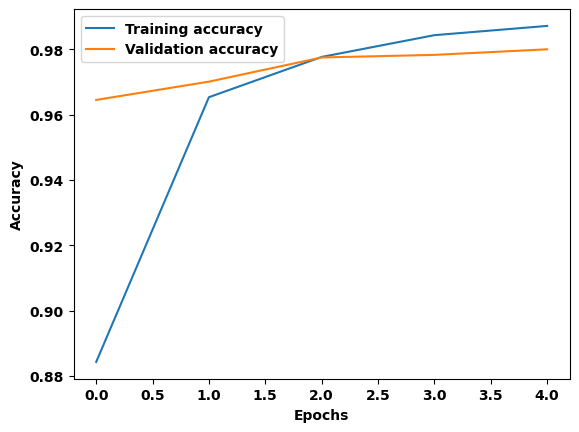

FOLD (array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[

Epoch 1/5
375/375 [==============================] - 8s 20ms/step - loss: 0.3392 - accuracy: 0.9003 - val_loss: 0.1410 - val_accuracy: 0.9586
Epoch 2/5
375/375 [==============================] - 7s 18ms/step - loss: 0.1000 - accuracy: 0.9704 - val_loss: 0.0783 - val_accuracy: 0.9769
Epoch 3/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0663 - accuracy: 0.9806 - val_loss: 0.0688 - val_accuracy: 0.9783
Epoch 4/5
375/375 [==============================] - 6s 16ms/step - loss: 0.0476 - accuracy: 0.9856 - val_loss: 0.0624 - val_accuracy: 0.9805
Epoch 5/5
313/313 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.96      0.99      0.97      1032
           3       1.00      0.94      0.97      1010
           4       0.99      0.98      0.98       982
           5       0.95      0.99      0.9

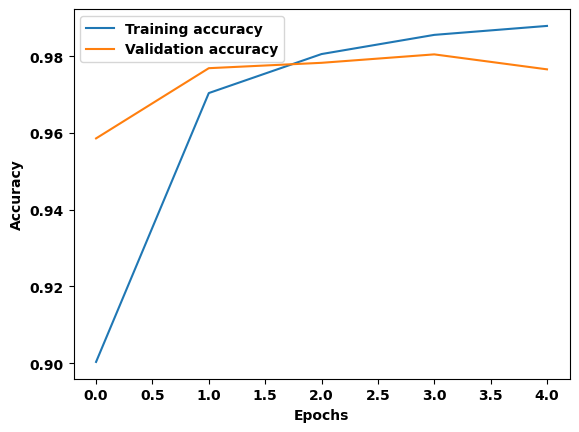

FOLD (array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[

In [2]:
from sklearn.metrics import classification_report
def train_and_verify(local_model, local_data, epochs, x_test, y_test, save_name):

    print(local_model)

    history = local_model.fit(local_data[0], local_data[1], epochs=epochs, validation_data=(x_test, y_test))
    y_pred = local_model.predict(x_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    print(classification_report(y_test, y_pred_classes))

    plt.plot(history.history['accuracy'], label='Training accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    local_model.save(save_name)

# Entrenamientos locales. Cada uno de estos deben hacerse en computadoras aparte.
from TheModel import build
from tqdm import tqdm
for x in tqdm(range(len(local_data)), desc=f"FOLD {x}"):
    local_model = build.build_it()
    train_and_verify(local_model, local_data[x], 5, x_test, y_test, f"lmodel_{x}.keras")

In [9]:
## Abrir los modelos:

import os
loaded_local_models = [tf.keras.models.load_model(os.path.join(root, file)) for root, dirs, files in os.walk("./") for file in files if file.endswith('.keras')]

for i in range(len(loaded_local_models)-1):
    assert loaded_local_models[i].summary() == loaded_local_models[i+1].summary(), "Models have different architectures"

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 1600)              0         
                                                                 
 dense_4 (Dense)             (None, 64)               

Epoch 1/5
1875/1875 [==============================] - 44s 23ms/step - loss: 0.1493 - accuracy: 0.9552 - val_loss: 0.0568 - val_accuracy: 0.9830
Epoch 2/5
1875/1875 [==============================] - 28s 15ms/step - loss: 0.0465 - accuracy: 0.9856 - val_loss: 0.0347 - val_accuracy: 0.9879
Epoch 3/5
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0332 - accuracy: 0.9898 - val_loss: 0.0325 - val_accuracy: 0.9889
Epoch 4/5
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0250 - accuracy: 0.9919 - val_loss: 0.0336 - val_accuracy: 0.9884
Epoch 5/5
313/313 [==============================] - 1s 3ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.98      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0

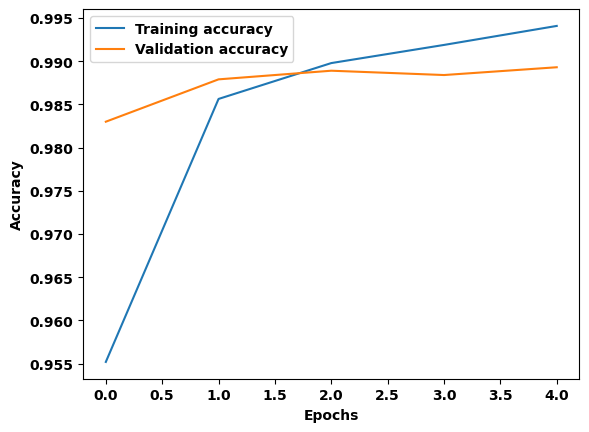

In [10]:
## VS A NORMAL GLOBLA MODEL TRAINED IN A SINGLE DEVICE:

model = build.build_it()

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

from sklearn.metrics import classification_report
# Predict the classes for the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

# Optionally, plot training history
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()